In [66]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

STATS_PATH = Path("/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/QBacMet/stats")

print("Stats path:", STATS_PATH)
print("Exists:", STATS_PATH.exists())

Stats path: /lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/QBacMet/stats
Exists: True


In [67]:
json_files = sorted(
	[f for f in STATS_PATH.iterdir() if f.suffix == ".json"]
)

print(f"Found {len(json_files)} JSON files:")
for f in json_files:
	print(" -", f.name)

Found 30 JSON files:
 - bit_code_nq15_ibmq_ibm_torino_CPU_sync_itrs1_20260225T135109Z.json
 - bit_code_nq16_ibmq_ibm_torino_CPU_sync_itrs1_20260225T031040Z.json
 - ghz_nq15_ibmq_ibm_miami_CPU_sync_itrs1_20260225T135237Z.json
 - ghz_nq15_ibmq_ibm_torino_CPU_sync_itrs1_20260225T135236Z.json
 - ghz_nq15_ionq_simulator_CPU_sync_itrs1_20260225T135235Z.json
 - ghz_nq15_nwqsim_MPI_CPU_sync_itrs1_20260225T135236Z.json
 - ghz_nq16_ibmq_ibm_miami_CPU_sync_itrs1_20260224T225602Z.json
 - ghz_nq16_ibmq_ibm_torino_CPU_sync_itrs1_20260224T225608Z.json
 - ghz_nq16_ionq_simulator_CPU_sync_itrs1_20260224T225606Z.json
 - ghz_nq16_nwqsim_MPI_CPU_sync_itrs1_20260224T225604Z.json
 - ham_nq15_ibmq_ibm_miami_CPU_sync_itrs1_20260225T140609Z.json
 - ham_nq15_ibmq_ibm_torino_CPU_sync_itrs1_20260225T140609Z.json
 - ham_nq15_nwqsim_MPI_CPU_sync_itrs1_20260225T140616Z.json
 - ham_nq16_ibmq_ibm_miami_CPU_sync_itrs1_20260225T020638Z.json
 - ham_nq16_ibmq_ibm_torino_CPU_sync_itrs1_20260225T020641Z.json
 - ham_nq16_nwq

In [68]:
def get_nested(d, keys, default=None):
	"""
	Safe nested dictionary access.
	Example:
		get_nested(entry, ["layers", "layer_1_algorithm", "metrics", "depth"])
	"""
	cur = d
	for k in keys:
		if not isinstance(cur, dict) or k not in cur:
			return default
		cur = cur[k]
	return cur

In [69]:
meta_rows = []
algo_rows = []
transpile_rows = []

for filepath in json_files:
	with open(filepath, "r") as f:
		entry = json.load(f)
	
	filename = filepath.name
	stem = filepath.stem
	
	args = entry.get("args", {})
	
	# ---------- META ----------
	meta_rows.append({
		"stem": stem,
		"filename": filename,
		"benchmark": args.get("benchmark_name"),
		"number_of_qubits": args.get("number_of_qubits"),
		"simulator_type": args.get("simulator_type"),
		"sub_backend": args.get("sub_backend"),
		"device": args.get("device"),
		"run_mode": args.get("run_mode"),
		"number_of_iterations": args.get("number_of_iterations"),
		"timestamp": entry.get("timestamp"),
	})
	
	# ---------- ALGORITHM LAYER (pre-transpile) ----------
	algo_metrics = get_nested(entry, ["layers", "layer_1_algorithm", "metrics"], {})
	algo_rows.append({
		"stem": stem,
		"algo_num_qubits": algo_metrics.get("num_qubits"),
		"algo_num_clbits": algo_metrics.get("num_clbits"),
		"algo_width": algo_metrics.get("width"),
		"algo_depth": algo_metrics.get("depth"),
		"algo_critical_path_length": algo_metrics.get("critical_path_length"),
		"algo_num_ops": algo_metrics.get("num_ops"),
		"algo_num_2q_gates": algo_metrics.get("num_2q_gates"),
		"algo_num_cliffords": algo_metrics.get("num_cliffords"),
		"algo_num_non_cliffords": algo_metrics.get("num_non_cliffords"),
		"algo_shots": algo_metrics.get("shots"),
		"algo_num_parameters": algo_metrics.get("num_parameters"),
		"algo_connected_components": algo_metrics.get("connected_components"),
		# Keep gate_counts as object for now (dict)
		"algo_gate_counts": algo_metrics.get("gate_counts"),
	})
	
	# ---------- TRANSPILE LAYER (post-transpile, backend-dependent) ----------
	trans_features = get_nested(entry, ["layers", "layer_2_transpile", "features"], {})
	trans_metrics = get_nested(entry, ["layers", "layer_2_transpile", "metrics"], {})
	transpile_rows.append({
		"stem": stem,
		"transpile_opt_level": trans_features.get("optimization_level"),
		"transpile_target": trans_features.get("target"),
		
		"hw_circ_depth": trans_metrics.get("hw_circ_depth"),
		"hw_circ_num_ops": trans_metrics.get("hw_circ_num_ops"),
		"hw_circ_num_2q_gates": trans_metrics.get("hw_circ_num_2q_gates"),
		"hw_circ_swaps": trans_metrics.get("hw_circ_swaps"),
		"hw_circ_width": trans_metrics.get("hw_circ_width"),
		"hw_circ_connected_components": trans_metrics.get("hw_circ_connected_components"),
		"hw_circ_connectivity_degree_max": trans_metrics.get("hw_circ_connectivity_degree_max"),
		"hw_circ_connectivity_degree_avg": trans_metrics.get("hw_circ_connectivity_degree_avg"),
		# Keep hw gate counts as object for now (dict)
		"hw_circ_gate_counts": trans_metrics.get("hw_circ_gate_counts"),
	})

print("Finished building row lists:")
print("  meta_rows      :", len(meta_rows))
print("  algo_rows      :", len(algo_rows))
print("  transpile_rows :", len(transpile_rows))

Finished building row lists:
  meta_rows      : 30
  algo_rows      : 30
  transpile_rows : 30


In [70]:
df_meta = pd.DataFrame(meta_rows).set_index("stem")
df_algo = pd.DataFrame(algo_rows).set_index("stem")
df_transpile = pd.DataFrame(transpile_rows).set_index("stem")

print("df_meta shape:", df_meta.shape)
print("df_algo shape:", df_algo.shape)
print("df_transpile shape:", df_transpile.shape)

# Full joined view for analyses
df_full = (
	df_meta
	.join(df_algo, how="left")
	.join(df_transpile, how="left")
)

df_full.head()

df_meta shape: (30, 9)
df_algo shape: (30, 13)
df_transpile shape: (30, 11)


,filename,benchmark,number_of_qubits,simulator_type,sub_backend,device,run_mode,number_of_iterations,timestamp,algo_num_qubits,...,transpile_target,hw_circ_depth,hw_circ_num_ops,hw_circ_num_2q_gates,hw_circ_swaps,hw_circ_width,hw_circ_connected_components,hw_circ_connectivity_degree_max,hw_circ_connectivity_degree_avg,hw_circ_gate_counts
stem,,,,,,,,,,,,,,,,,,,,,
bit_code_nq15_ibmq_ibm_torino_CPU_sync_itrs1_20260225T135109Z,bit_code_nq15_ibmq_ibm_torino_CPU_sync_itrs1_2...,bit_code,15,ibmq,ibm_torino,CPU,sync,1,2026-02-25T13:51:09.265785Z,29.0,...,<class 'qiskit.transpiler.target.Target'>,11.0,169.0,28.0,0.0,133.0,105.0,2.0,0.421053,"{'cz': 28, 'measure': 43, 'reset': 14, 'rz': 5..."
bit_code_nq16_ibmq_ibm_torino_CPU_sync_itrs1_20260225T031040Z,bit_code_nq16_ibmq_ibm_torino_CPU_sync_itrs1_2...,bit_code,16,ibmq,ibm_torino,CPU,sync,1,2026-02-25T03:10:40.067089Z,31.0,...,<class 'qiskit.transpiler.target.Target'>,11.0,181.0,30.0,0.0,133.0,103.0,2.0,0.451128,"{'cz': 30, 'measure': 46, 'reset': 15, 'rz': 6..."
ghz_nq15_ibmq_ibm_miami_CPU_sync_itrs1_20260225T135237Z,ghz_nq15_ibmq_ibm_miami_CPU_sync_itrs1_2026022...,ghz,15,ibmq,ibm_miami,CPU,sync,1,2026-02-25T13:52:37.405338Z,15.0,...,<class 'qiskit.transpiler.target.Target'>,60.0,116.0,14.0,0.0,120.0,106.0,2.0,0.233333,"{'cz': 14, 'measure': 15, 'rz': 58, 'sx': 29}"
ghz_nq15_ibmq_ibm_torino_CPU_sync_itrs1_20260225T135236Z,ghz_nq15_ibmq_ibm_torino_CPU_sync_itrs1_202602...,ghz,15,ibmq,ibm_torino,CPU,sync,1,2026-02-25T13:52:36.742736Z,15.0,...,<class 'qiskit.transpiler.target.Target'>,60.0,116.0,14.0,0.0,133.0,119.0,2.0,0.210526,"{'cz': 14, 'measure': 15, 'rz': 58, 'sx': 29}"
ghz_nq15_ionq_simulator_CPU_sync_itrs1_20260225T135235Z,ghz_nq15_ionq_simulator_CPU_sync_itrs1_2026022...,ghz,15,ionq,simulator,CPU,sync,1,2026-02-25T13:52:35.799151Z,15.0,...,<class 'NoneType'>,16.0,30.0,14.0,0.0,15.0,1.0,2.0,1.866667,"{'cx': 14, 'h': 1, 'measure': 15}"


In [71]:
# Parse timestamp
df_full["timestamp"] = pd.to_datetime(df_full["timestamp"], errors="coerce")

# Numeric columns we care about for PCA / clustering
numeric_cols = [
	"number_of_qubits",
	"algo_num_qubits",
	"algo_num_clbits",
	"algo_width",
	"algo_depth",
	"algo_critical_path_length",
	"algo_num_ops",
	"algo_num_2q_gates",
	"algo_num_cliffords",
	"algo_num_non_cliffords",
	"algo_shots",
	"algo_num_parameters",
	"algo_connected_components",
	
	"hw_circ_depth",
	"hw_circ_num_ops",
	"hw_circ_num_2q_gates",
	"hw_circ_swaps",
	"hw_circ_width",
	"hw_circ_connected_components",
	"hw_circ_connectivity_degree_max",
	"hw_circ_connectivity_degree_avg",
]

for col in numeric_cols:
	if col in df_full.columns:
		df_full[col] = pd.to_numeric(df_full[col], errors="coerce")

df_full.dtypes.head(20)

filename                                     str
benchmark                                    str
number_of_qubits                           int64
simulator_type                               str
sub_backend                                  str
device                                       str
run_mode                                     str
number_of_iterations                       int64
timestamp                    datetime64[us, UTC]
algo_num_qubits                          float64
algo_num_clbits                            int64
algo_width                                 int64
algo_depth                                 int64
algo_critical_path_length                  int64
algo_num_ops                               int64
algo_num_2q_gates                          int64
algo_num_cliffords                         int64
algo_num_non_cliffords                     int64
algo_shots                               float64
algo_num_parameters                        int64
dtype: object

In [72]:
# --- Algorithm-space analysis parameters ---
NQ = 15

algo_features = [
	"algo_depth",
	"algo_num_ops",
	"algo_num_2q_gates",
	"algo_num_cliffords",
	"algo_num_non_cliffords",
	"algo_critical_path_length",
	"algo_width",
	"algo_connected_components",
]

df_algo_nq = df_full[df_full["number_of_qubits"] == NQ].copy()
df_algo_nq = df_algo_nq.dropna(subset=algo_features)

print("Rows in algorithm analysis (nq = {}): {}".format(NQ, df_algo_nq.shape[0]))
df_algo_nq[["benchmark"] + algo_features].head()

Rows in algorithm analysis (nq = 15): 14


,benchmark,algo_depth,algo_num_ops,algo_num_2q_gates,algo_num_cliffords,algo_num_non_cliffords,algo_critical_path_length,algo_width,algo_connected_components
stem,,,,,,,,,
bit_code_nq15_ibmq_ibm_torino_CPU_sync_itrs1_20260225T135109Z,bit_code,5,85,28,28,57,5,29,1
ghz_nq15_ibmq_ibm_miami_CPU_sync_itrs1_20260225T135237Z,ghz,16,30,14,15,15,16,15,1
ghz_nq15_ibmq_ibm_torino_CPU_sync_itrs1_20260225T135236Z,ghz,16,30,14,15,15,16,15,1
ghz_nq15_ionq_simulator_CPU_sync_itrs1_20260225T135235Z,ghz,16,30,14,15,15,16,15,1
ghz_nq15_nwqsim_MPI_CPU_sync_itrs1_20260225T135236Z,ghz,16,30,14,15,15,16,15,1


In [73]:
# Average algorithm metrics per benchmark
df_algo_summary = (
	df_algo_nq
	.groupby("benchmark")[algo_features]
	.mean()
	.sort_values("algo_depth")
)

df_algo_summary

,algo_depth,algo_num_ops,algo_num_2q_gates,algo_num_cliffords,algo_num_non_cliffords,algo_critical_path_length,algo_width,algo_connected_components
benchmark,,,,,,,,
bit_code,5.0,85.0,28.0,28.0,57.0,5.0,29.0,1.0
phase_code,8.0,173.0,28.0,116.0,57.0,8.0,29.0,1.0
ghz,16.0,30.0,14.0,15.0,15.0,16.0,15.0,1.0
ham,46.0,102.0,28.0,58.0,44.0,46.0,15.0,1.0
mermin_bell,73.0,199.0,139.0,183.0,16.0,73.0,15.0,1.0
nqmatrix6,90955.0,91054.0,128.0,151.0,90904.0,90956.0,15.0,1.0


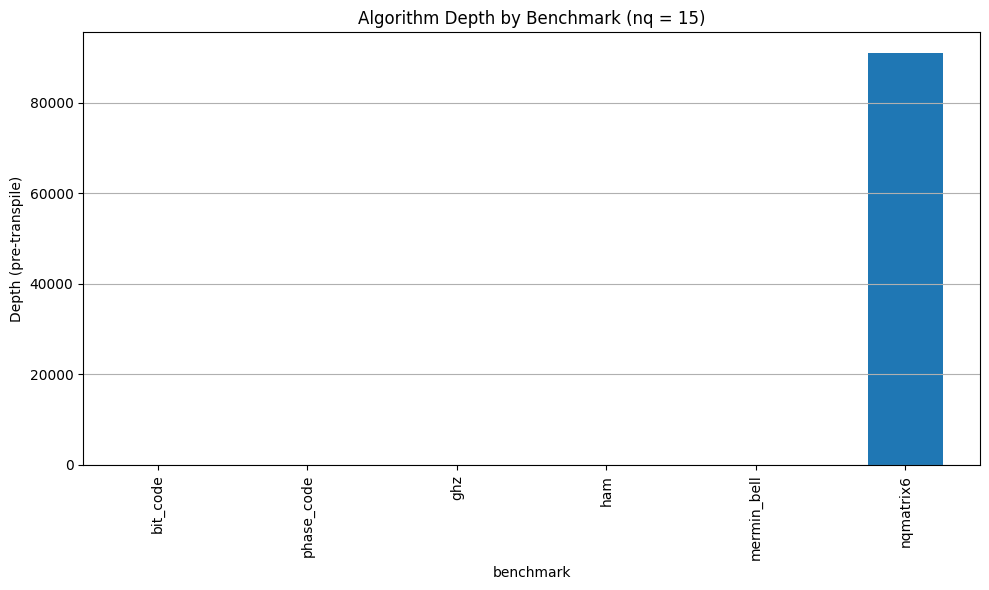

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df_algo_summary["algo_depth"].plot(kind="bar")
plt.ylabel("Depth (pre-transpile)")
plt.title(f"Algorithm Depth by Benchmark (nq = {NQ})")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

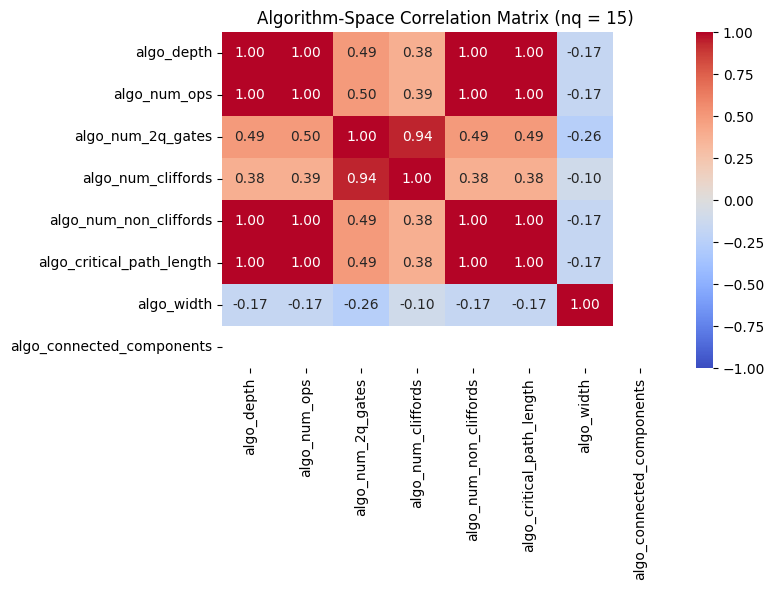

In [75]:
import seaborn as sns

corr_algo = df_algo_nq[algo_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_algo, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title(f"Algorithm-Space Correlation Matrix (nq = {NQ})")
plt.tight_layout()
plt.show()

In [ ]:
# Normalize features per column (z-score) to compare shapes
df_algo_norm = (
	df_algo_summary
	.copy()
)

df_algo_norm = (df_algo_norm - df_algo_norm.mean()) / df_algo_norm.std()

df_algo_norm

In [ ]:
# Plot normalized metrics for each benchmark as grouped bar
plt.figure(figsize=(12, 6))
df_algo_norm.T.plot(kind="bar")  # transpose so metrics on x-axis
plt.ylabel("Normalized value (z-score)")
plt.title(f"Normalized Algorithm Metrics by Benchmark (nq = {NQ})")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

X_algo = df_algo_nq[algo_features].values
X_algo_scaled = StandardScaler().fit_transform(X_algo)

pca_algo = PCA(n_components=2)
X_algo_pca = pca_algo.fit_transform(X_algo_scaled)

print("Explained variance (PC1, PC2):", pca_algo.explained_variance_ratio_)

# Loadings tell you what each PC is made of
loadings_algo = pd.DataFrame(
	pca_algo.components_.T,
	index=algo_features,
	columns=["PC1", "PC2"]
)
loadings_algo

In [ ]:
plt.figure(figsize=(10, 6))
for bench in df_algo_nq["benchmark"].unique():
	idx = df_algo_nq["benchmark"] == bench
	plt.scatter(X_algo_pca[idx, 0], X_algo_pca[idx, 1], label=bench, s=80)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Algorithm-Space PCA (pre-transpile, nq = {NQ})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Transpile-space analysis parameters ---

In [ ]:
transpile_features = [
	"hw_circ_depth",
	"hw_circ_num_ops",
	"hw_circ_num_2q_gates",
	"hw_circ_swaps",
	"hw_circ_width",
	"hw_circ_connected_components",
	"hw_circ_connectivity_degree_avg",
	"hw_circ_connectivity_degree_max",
]

df_tp_nq = df_full[df_full["number_of_qubits"] == NQ].copy()
df_tp_nq = df_tp_nq.dropna(subset=transpile_features)

print("Rows in transpile analysis (nq = {}): {}".format(NQ, df_tp_nq.shape[0]))
df_tp_nq[["benchmark", "sub_backend"] + transpile_features].head()

In [ ]:
df_backend_summary = (
	df_tp_nq
	.groupby("sub_backend")[transpile_features]
	.mean()
	.sort_values("hw_circ_depth")
)

df_backend_summary

In [ ]:
plt.figure(figsize=(10, 6))
df_backend_summary["hw_circ_depth"].plot(kind="bar")
plt.ylabel("HW depth (post-transpile)")
plt.title(f"Average HW Circuit Depth by Backend (nq = {NQ})")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
pivot_depth = (
	df_tp_nq
	.pivot_table(
		index="benchmark",
		columns="sub_backend",
		values="hw_circ_depth",
		aggfunc="mean"
	)
)

pivot_depth

In [ ]:
plt.figure(figsize=(10, 6))
pivot_depth.plot(kind="bar")
plt.ylabel("HW depth")
plt.title(f"HW Circuit Depth by Benchmark and Backend (nq = {NQ})")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
pivot_2q = (
	df_tp_nq
	.pivot_table(
		index="benchmark",
		columns="sub_backend",
		values="hw_circ_num_2q_gates",
		aggfunc="mean"
	)
)

plt.figure(figsize=(10, 6))
pivot_2q.plot(kind="bar")
plt.ylabel("HW 2Q gate count")
plt.title(f"HW 2Q Gates by Benchmark and Backend (nq = {NQ})")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
corr_tp = df_tp_nq[transpile_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_tp, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title(f"Transpile-Space Correlation Matrix (nq = {NQ})")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 8))

backends = df_tp_nq["sub_backend"].unique()
for backend in backends:
	sub = df_tp_nq[df_tp_nq["sub_backend"] == backend]
	plt.scatter(
		sub["algo_depth"],
		sub["hw_circ_depth"],
		label=backend,
		s=80,
		alpha=0.8
	)

max_depth = max(df_tp_nq["algo_depth"].max(), df_tp_nq["hw_circ_depth"].max())
plt.plot([0, max_depth], [0, max_depth], "k--", label="y = x")


plt.xlim(0, 100)

plt.xlabel("Algorithm depth (pre-transpile)")
plt.ylabel("HW depth (post-transpile)")
plt.title(f"Depth Inflation by Backend (nq = {NQ})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
## Pre vs Post

In [ ]:
df_delta = df_full[df_full["number_of_qubits"] == NQ].copy()

df_delta["depth_increase"] = df_delta["hw_circ_depth"] - df_delta["algo_depth"]
df_delta["twoq_increase"] = df_delta["hw_circ_num_2q_gates"] - df_delta["algo_num_2q_gates"]

df_delta["depth_ratio"] = df_delta["hw_circ_depth"] / df_delta["algo_depth"]
df_delta["twoq_ratio"] = df_delta["hw_circ_num_2q_gates"] / df_delta["algo_num_2q_gates"]

delta_features = ["depth_increase", "twoq_increase", "depth_ratio", "twoq_ratio"]

df_delta = df_delta.dropna(subset=delta_features)
df_delta[["benchmark", "sub_backend"] + delta_features].head()

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
	data=df_delta,
	x="sub_backend",
	y="depth_ratio"
)
plt.axhline(1.0, color="k", linestyle="--")
plt.ylabel("Depth ratio (HW depth / algo depth)")
plt.title(f"Depth Inflation by Backend (nq = {NQ})")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
	data=df_delta,
	x="benchmark",
	y="depth_ratio"
)
plt.axhline(1.0, color="k", linestyle="--")
plt.ylabel("Depth ratio (HW depth / algo depth)")
plt.title(f"Depth Inflation by Benchmark (nq = {NQ})")
plt.tight_layout()
plt.show()

In [ ]:
pivot_ratio = (
	df_delta
	.pivot_table(
		index="benchmark",
		columns="sub_backend",
		values="depth_ratio",
		aggfunc="mean"
	)
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_ratio, annot=True, fmt=".2f", cmap="viridis")
plt.title(f"Mean Depth Ratio (HW / Algo) by Benchmark & Backend (nq = {NQ})")
plt.tight_layout()
plt.show()